In [8]:
#Chi-squared
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.feature_selection import SelectKBest, chi2
import time

X_train_cv=sparse.load_npz("X_train_cv.npz")
X_test_cv=sparse.load_npz("X_test_cv.npz")
y_train=pd.read_csv("y_train.csv")
y_test=pd.read_csv("y_test.csv")
print("Data loaded")
print(X_train_cv.shape)

start=time.time()
chi2selector=SelectKBest(chi2,k=1000)
X_train_chi2=chi2selector.fit_transform(X_train_cv,y_train)
X_test_chi2=chi2selector.transform(X_test_cv)
end=time.time()
print(f"Time taken: {end-start:.2f} seconds")
print(X_train_chi2.shape)


Data loaded
(25000, 5000)
Time taken: 0.14 seconds
(25000, 1000)


In [2]:
#Truncated SVD
from sklearn.decomposition import TruncatedSVD
X_train_tfidf=sparse.load_npz("X_train_tfidf.npz")
X_test_tfidf=sparse.load_npz("X_test_tfidf.npz")
print(X_train_tfidf.shape)
start=time.time()
svd=TruncatedSVD(n_components=1000, random_state=42)
X_train_svd=svd.fit_transform(X_train_tfidf)
X_test_svd=svd.transform(X_test_tfidf)
end=time.time()
print(X_train_svd.shape)
print(f"Time taken: {end-start:.2f} seconds")
print(f"Variance retained: {svd.explained_variance_ratio_.sum()*100:.1f}%")

(25000, 5000)
(25000, 1000)
Time taken: 31.80 seconds
Variance retained: 54.8%


In [3]:
np.save("X_train_svd.npy", X_train_svd)
np.save("X_test_svd.npy", X_test_svd)
print("SVD saved!")


SVD saved!


In [4]:
sparse.save_npz("X_train_chi2.npz", X_train_chi2)
sparse.save_npz("X_test_chi2.npz", X_test_chi2)
print("Chi2 saved!")

Chi2 saved!


In [12]:
from sklearn.decomposition import PCA
X_train_glove=np.load("X_train_glove.npy")
X_test_glove=np.load("X_test_glove.npy")
print(X_train_glove.shape)
start=time.time()
pca=PCA(n_components=50, random_state=42)
X_train_pca=pca.fit_transform(X_train_glove)
X_test_pca=pca.transform(X_test_glove)
end=time.time()
print(X_train_pca.shape)
print(f"Time talen: {end-start:.2f} seconds")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

(25000, 100)
(25000, 50)
Time talen: 0.04 seconds
Variance retained: 88.1%


Time taken: 22.38 seconds


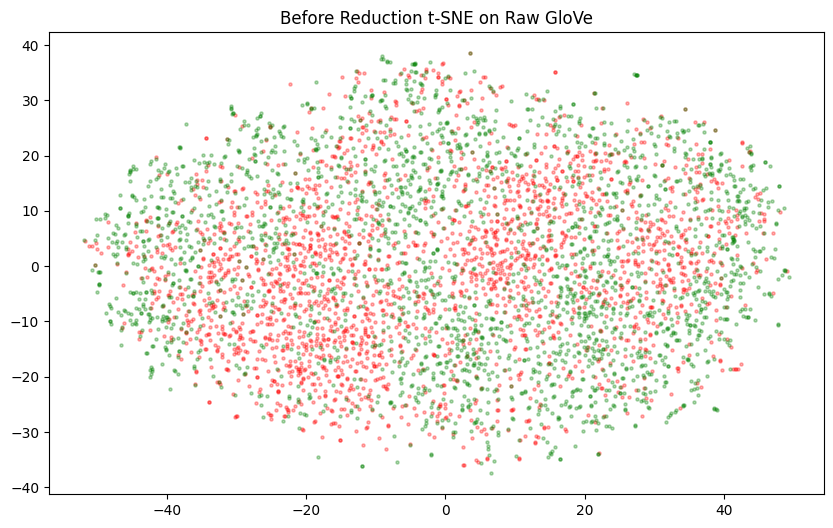

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
indices=np.random.permutation(25000)[:5000]
X_subset=X_train_glove[indices]
y_train_np = pd.read_csv("y_train.csv").squeeze().to_numpy()
y_subset=y_train_np[indices]

start=time.time()
tsne=TSNE(n_components=2,random_state=42)
X_2d=tsne.fit_transform(X_subset)
end=time.time()
print(f"Time taken: {end-start:.2f} seconds")

plt.figure(figsize=(10,6))
plt.scatter(X_2d[y_subset==0,0], X_2d[y_subset==0,1], c="red", alpha=0.3, label="Negative", s=5)
plt.scatter(X_2d[y_subset==1,0], X_2d[y_subset==1,1], c="green", alpha=0.3, label="Positive", s=5)
plt.title("Before Reduction t-SNE on Raw GloVe")
plt.show()

Time taken: 18.60 seconds


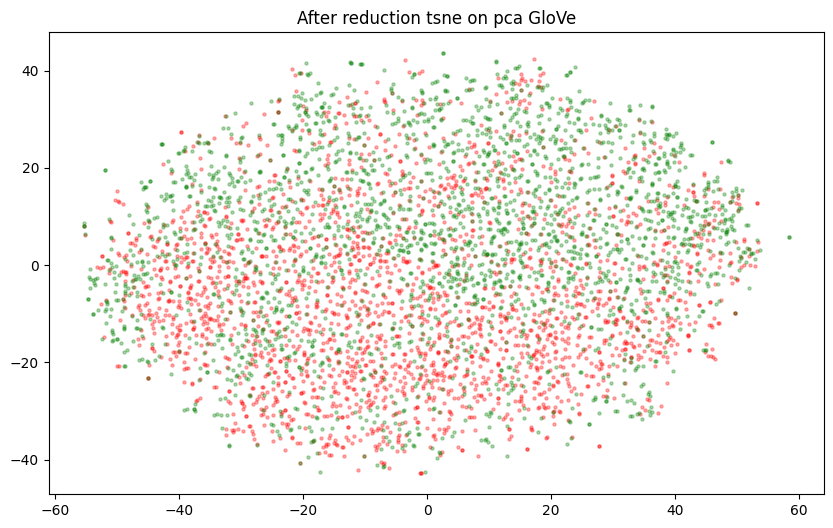

In [18]:
from sklearn.manifold import TSNE
indices=np.random.permutation(25000)[:5000]
X_subset=X_train_pca[indices]
y_subset=y_train_np[indices]

start=time.time()
tsne=TSNE(n_components=2,random_state=42)
X_2d=tsne.fit_transform(X_subset)
end=time.time()
print(f"Time taken: {end-start:.2f} seconds")

plt.figure(figsize=(10,6))
plt.scatter(X_2d[y_subset==0,0], X_2d[y_subset==0,1], c="red", alpha=0.3, label="Negative", s=5)
plt.scatter(X_2d[y_subset==1,0], X_2d[y_subset==1,1], c="green", alpha=0.3, label="Positive", s=5)
plt.title("After reduction tsne on pca GloVe")
plt.show()

In [13]:
import numpy as np

np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy", X_test_pca)
print("PCA saved!")

PCA saved!


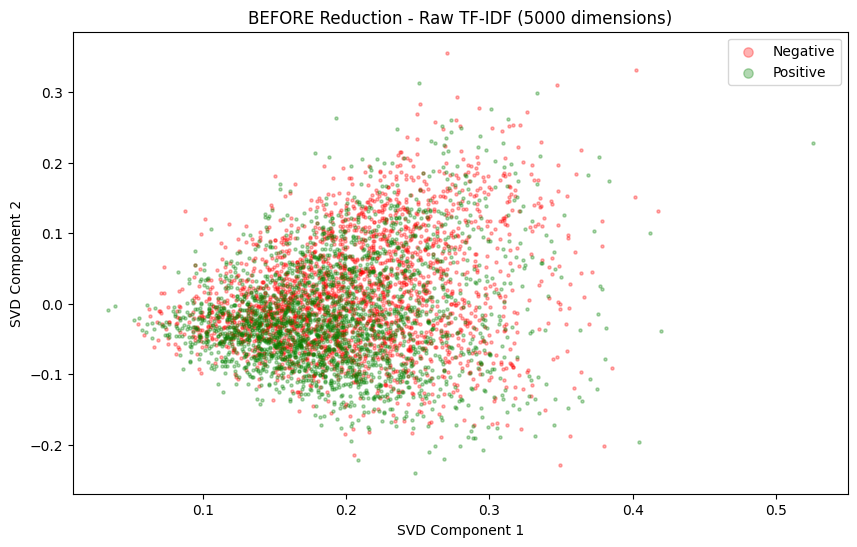

In [14]:
y_train_np = pd.read_csv("y_train.csv").squeeze().to_numpy()
X_train_tfidf = sparse.load_npz("X_train_tfidf.npz")

svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_tfidf_2d = svd_2d.fit_transform(X_train_tfidf)

indices = np.random.permutation(25000)[:5000]
X_subset = X_tfidf_2d[indices]
y_subset = y_train_np[indices]

plt.figure(figsize=(10, 6))
plt.scatter(X_subset[y_subset==0, 0], X_subset[y_subset==0, 1], c="red", alpha=0.3, label="Negative", s=5)
plt.scatter(X_subset[y_subset==1, 0], X_subset[y_subset==1, 1], c="green", alpha=0.3, label="Positive", s=5)
plt.title("BEFORE Reduction - Raw TF-IDF (5000 dimensions)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(markerscale=3)
plt.savefig("tfidf_before.png", dpi=150, bbox_inches="tight")
plt.show()

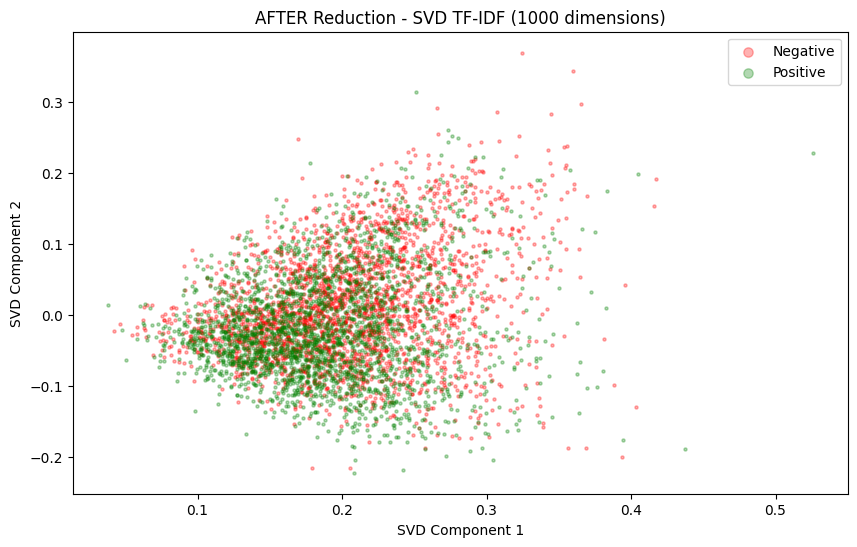

In [16]:
X_train_svd = np.load("X_train_svd.npy")

svd_2d_after = TruncatedSVD(n_components=2, random_state=42)
X_svd_2d = svd_2d_after.fit_transform(X_train_svd)

indices = np.random.permutation(25000)[:5000]
X_subset = X_svd_2d[indices]
y_subset = y_train_np[indices]

plt.figure(figsize=(10, 6))
plt.scatter(X_subset[y_subset==0, 0], X_subset[y_subset==0, 1], c="red", alpha=0.3, label="Negative", s=5)
plt.scatter(X_subset[y_subset==1, 0], X_subset[y_subset==1, 1], c="green", alpha=0.3, label="Positive", s=5)
plt.title("AFTER Reduction - SVD TF-IDF (1000 dimensions)")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(markerscale=3)
plt.savefig("tfidf_after.png", dpi=150, bbox_inches="tight")
plt.show()